# Lab 04: Coffeehouse Competition - Spatial Enabled Dataframes

Welcome to the world of exploring the coffee marketplace in Arizona!

In this notebook you will work with spatially enabled dataframes to map and analyze the locations of Starbucks and Dutch Bros stores. You'll compute nearest‑neighbour distances, perform basic statistical comparisons and experiments.

How does DutchBros compete when Starbucks has a store seemingly on every corner? Dutch Bros is a newer chain that has been rapidly opening stores in a number of metro areas. 

Where should Dutch Bros put their new stores relative to Starbucks? One strategy of competing chains is to put stores right next to their competitor's popular stores. Another strategy is to try to find areas away from competitor stores to attract costumers that are not close to an existing competitor store. What strategy is Dutch Bros using? In this project we are going to look at location data to try to determine what their strategy has been

All data you need (`starbucks_AZ.csv` and `dutch.csv`) are included with your course materials. Follow each section below, filling in the code where indicated and answering the questions in markdown cells.

## 1. Setup
First, import the libraries you will need. We'll work with **pandas** and **numpy** for data handling, **arcgis** for spatially enabled dataframes and mapping, **matplotlib**, **seaborn** or **plotly** for visualization, and **scipy** for basic statistics.


In [29]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
from arcgis.gis import GIS # for connecting to ArcGIS
from arcgis.features import GeoAccessor # for working with spatial data
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for enhanced plotting
from scipy.stats import ranksums # for statistical tests

In [30]:
# Connect to ArcGIS Online 
gis = GIS("pro") # Use 'pro' to connect using ArcGIS Pro credentials
print(f'Logged in as: {gis.properties.user.username}') # Display the username

Logged in as: adrawal_asu


## 2. Load the coffee shop datasets
Load the CSV files containing Starbucks and Dutch Bros locations. Inspect the first few rows to understand the fields. For the Starbucks data the latitude and longitude columns are called `latitude` and `longitude`; for the Dutch Bros data they are `Y` and `X`.


In [31]:
# Load the given data
df_star = pd.read_csv("./starbucks_AZ.csv") # Load Starbucks data
df_dutch = pd.read_csv("./dutch.csv")  # Load Dutch Bros data

# inspect the first few rows of each dataframe
df_star.head()

,oldid,city,country,latitude,longitude,name,store_id
0,4151,Scottsdale,US,33.781139,-111.922531,Safeway - Scottsdale #1849,6453
1,4281,Phoenix,US,33.640507,-112.133507,Safeway - Phoenix #240,6601
2,4317,Gilbert,US,33.348576,-111.720100,Bashas - Gilbert/Higley Rd #172,6643
3,4318,Chandler,US,33.319832,-111.891426,"Ray Road & Loop 101, Chandler",6644
4,4326,Goodyear,US,33.465324,-112.341660,"Dysart & McDowell, Goodyear",6655


In [32]:
# Check the number of points in each dataset
print(f"\nNumber of points:")
print(f"Dutch Bros: {len(df_dutch)} locations")
print(f"Starbucks: {len(df_star)} locations")


Number of points:
Dutch Bros: 28 locations
Starbucks: 326 locations


## 3. Convert to spatially enabled dataframes (SEDFs)
Use `GeoAccessor.from_xy()` to convert pandas DataFrames into spatially enabled dataframes. This will allow you to perform spatial operations and visualize the points on a map easily. Use EPSG:4326 for lat/lon.


In [33]:
# create SEDF for Dutch Bros
sdf_dutch = GeoAccessor.from_xy(
    df_dutch,
    x_column="X",
    y_column="Y",
    sr=4326
) # Convert df_dutch to SEDF, specifying x and y columns and WGS84 spatial reference
sdf_star = GeoAccessor.from_xy(
    df_star,
    x_column="longitude",
    y_column="latitude",
    sr=4326
) # Convert df_star to SEDF, specifying x and y columns and WGS84 spatial reference

In [34]:
# inspect the first few rows of each SEDF. You should see a new 'SHAPE' column
sdf_dutch.head()
sdf_star.head()

,oldid,city,country,latitude,longitude,name,store_id,SHAPE
0,4151,Scottsdale,US,33.781139,-111.922531,Safeway - Scottsdale #1849,6453,"{""spatialReference"": {""wkid"": 4326}, ""x"": -111..."
1,4281,Phoenix,US,33.640507,-112.133507,Safeway - Phoenix #240,6601,"{""spatialReference"": {""wkid"": 4326}, ""x"": -112..."
2,4317,Gilbert,US,33.348576,-111.720100,Bashas - Gilbert/Higley Rd #172,6643,"{""spatialReference"": {""wkid"": 4326}, ""x"": -111..."
3,4318,Chandler,US,33.319832,-111.891426,"Ray Road & Loop 101, Chandler",6644,"{""spatialReference"": {""wkid"": 4326}, ""x"": -111..."
4,4326,Goodyear,US,33.465324,-112.341660,"Dysart & McDowell, Goodyear",6655,"{""spatialReference"": {""wkid"": 4326}, ""x"": -112..."


In [35]:
# display spatial reference and additional spatial info
print("Dutch Bros Spatial Reference:") 
print(sdf_dutch.spatial.sr) # Use df.spatial.sr to get spatial reference
print("\nStarbucks Spatial Reference:")
print(sdf_star.spatial.sr) # Use df.spatial.sr to get spatial reference

Dutch Bros Spatial Reference:
SpatialReference({'wkid': 4326})

Starbucks Spatial Reference:
SpatialReference({'wkid': 4326})


## 4. Visualize the coffee shops on a map
Create an interactive map centered on Phoenix and add both chains as layers. Customize symbology so it's easy to distinguish the chains.


In [36]:
coffee_map = gis.map('Phoenix, AZ') # Create a map centered on Phoenix, AZ

In [37]:
# SimpleRenderer for Starbucks
star_renderer = {
    "type": "simple",
    "symbol": {
        "type": "esriSMS",
        "style": "esriSMSCircle",
        "color": [0, 112, 255, 120], # blue with transparency
        "size": 10,
        "outline": {
            "type": "esriSLS",
            "style": "esriSLSSolid",
            "color": [0, 90, 200, 200], # blue outline
            "width": 0.5
        }
    }
}
# SimpleRenderer for Dutch Bros
dutch_renderer = {
    "type": "simple",
    "symbol": {
        "type": "esriSMS",
        "style": "esriSMSTriangle",
        "color": [255, 0, 128, 120], # pink with transparency
        "size": 10,
        "outline": {
            "type": "esriSLS",
            "style": "esriSLSSolid",
            "color": [220, 0, 110, 200], # pink outline
            "width": 0.5
        }
    }
}

In [38]:
# Convert Spatially Enabled DataFrames to FeatureCollections
star_fc = sdf_star.spatial.to_feature_collection(name="Starbucks Locations")
# Convert Starbucks SEDF to FeatureCollection
dutch_fc = sdf_dutch.spatial.to_feature_collection(name="Dutch Bros Locations") # Convert Dutch Bros SEDF to FeatureCollection

In [39]:
# Plot both datasets on the map with their respective renderers
sdf_star.spatial.plot(
    map_widget=coffee_map,
    renderer=star_renderer,
    name="Starbucks Locations"
)
sdf_dutch.spatial.plot(
    map_widget=coffee_map,
    renderer=dutch_renderer,
    name="Dutch Bros Locations"
)

True

In [40]:
coffee_map # display the map

Map(center=[3954947.783337919, -12475863.07182197], extent={'xmin': -12504583.500446636, 'ymin': 3920577.66229…

<b>Now that you can see the locations on a map, does it appear that Dutch Bros is trying to avoid being too close to Starbucks?</b>

Please write a couple sentences here:-

Dutch Bros and Starbucks frequently operate within the same general areas, but generally, Dutch Bros sites appear to maintain a modest buffer, rather than locating directly adjacent to existing Starbucks stores. The two networks overlap across the metro, but Dutch Bros tends to position itself just outside the densest Starbucks clusters, suggesting a strategy of capturing similar customer flows while minimizing direct competition.

## 5. Compute nearest‑neighbor distances
### 5.1 Haversine distance function
Implement a Haversine function to compute distances between two (lat, lon) points. We'll use it later to compute nearest neighbor distances.


In [41]:
# Haversine formula to calculate great-circle distances

import math

def haversine(Y, X, longitude, latitude):
    '''Compute great‑circle distance between two points in kilometers.'''
    # convert decimal degrees to radians
    Y, X, longitude, latitude = map(math.radians, [Y, X, longitude, latitude])
    dlon = longitude - Y
    dlat = latitude - X
    a = math.sin(dlat/2)**2 + math.cos(X) * math.cos(latitude) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    km = 6367 * c
    return km

### 5.2 Nearest Starbucks for each Dutch Bros
Compute the distance from each Dutch Bros store to its nearest Starbucks store using nested loops. Store the results in a list or Series.


In [42]:
    coords_star = sdf_star[['SHAPE']].apply(lambda row: (row['SHAPE'].y, row['SHAPE'].x), axis=1).tolist() # extract (lat, lon) for Starbucks into a list
    coords_dutch = sdf_dutch[['SHAPE']].apply(lambda row: (row['SHAPE'].y, row['SHAPE'].x), axis=1).tolist() # extract (lat, lon) for Dutch Bros into a list

    nearest_dutch_star = [] # Empty list to store nearest distances from Dutch Bros to Starbucks
    # For each Dutch Bros location, find the nearest Starbucks location
    for dy, dx in coords_dutch:
        min_d = float('inf') # Initialize minimum distance to infinity
        # Check distance to each Starbucks location
        for sy, sx in coords_star:
            d = haversine(dy, dx, sy, sx) # Calculate distance
            # Update minimum distance if current distance is smaller
            if d < min_d:
                min_d = d
        nearest_dutch_star.append(min_d) # Append nearest distance to the list

    nearest_dutch_star = pd.Series(nearest_dutch_star) # Convert list to Pandas Series for easier handling
    nearest_dutch_star.head() # Display first few nearest distances from Dutch Bros to Starbucks

0    0.281289
1    1.020284
2    1.170969
3    0.302623
4    0.487345
dtype: float64

### 5.3 Nearest Starbucks for each Starbucks (excluding itself)
Compute the distance to the nearest other Starbucks store for every Starbucks.


In [43]:
nearest_star_star = [] # Empty list to store nearest distances from Starbucks to other Starbucks
# For each Starbucks location, find the nearest other Starbucks location
for sx, sy in coords_star:
    min_d = float('inf')  # Initialize minimum distance to infinity
    # Check distance to each other Starbucks location
    for ix, iy in coords_star:
        # Skip distance to itself
        if (sx, sy) == (ix, iy):
            continue
            
        d = haversine(sx, sy, ix, iy)  # Calculate distance
        # Update minimum distance if current distance is smaller
        if d < min_d:
            min_d = d
    nearest_star_star.append(min_d)  # Append nearest distance to the list
# Convert list to Pandas Series for easier handling
nearest_star_star = pd.Series(nearest_star_star)
nearest_star_star.head() # Display first few nearest distances from Starbucks to other Starbucks

0    0.073246
1    1.496971
2    1.268060
3    1.179402
4    0.124421
dtype: float64

## 6. Summarize the distance patterns
Calculate median distances and visualize the distributions with overlapping histograms.


Median Dutch to Starbucks distance: 0.8 m
Median Starbucks to Starbucks distance: 0.5 m


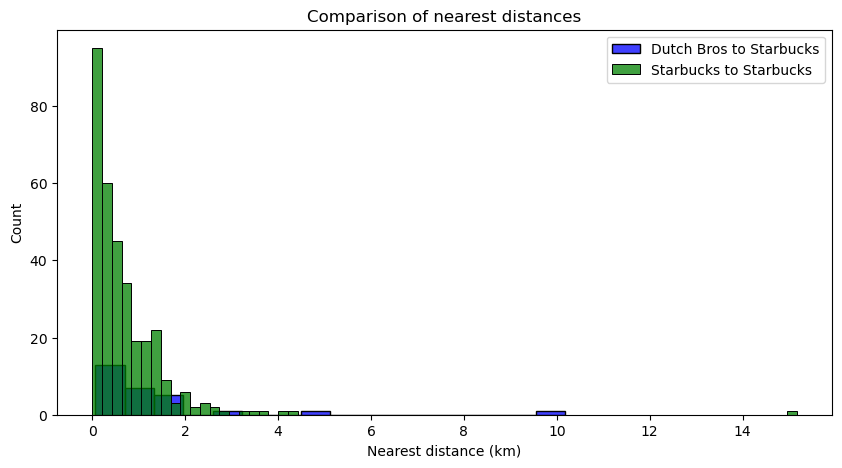

In [44]:
med_dutch_star = nearest_dutch_star.median() # Calculate median distance from Dutch Bros to Starbucks
med_star_star = nearest_star_star.median() # Calculate median distance from Starbucks to other Starbucks
print(f'Median Dutch to Starbucks distance: {med_dutch_star:.1f} m')
print(f'Median Starbucks to Starbucks distance: {med_star_star:.1f} m')

plt.figure(figsize=(10, 5)) # Set figure size to 10x5 inches
sns.histplot(nearest_dutch_star, color='blue', label='Dutch Bros to Starbucks', kde=False) # Plot histogram for Dutch Bros to Starbucks
sns.histplot(nearest_star_star, color='green', label='Starbucks to Starbucks', kde=False) # Plot histogram for Starbucks to Starbucks
plt.xlabel('Nearest distance (km)') # xlabel for the plot: Nearest distance (km)
plt.ylabel('Count') # ylabel for the plot: Count
plt.title('Comparison of nearest distances') # title for the plot: Comparison of nearest distances
plt.legend() # legend for the plot
plt.show() # display the plot

We can ask whether the Dutch Bros stores are further (or closer) to Starbucks stores than Starbucks is to itself. If the Dutch Bros are farther to Starbucks than Starbucks to Starbucks, it is likely that Dutch Bros is avoiding being close to Starbucks.

### 6.1 Statistical comparison
Use the Wilcoxon rank‑sum test to compare the distance distributions. A low p-value indicates significant difference.


In [45]:
stat, p = ranksums(nearest_dutch_star, nearest_star_star)  # Perform Wilcoxon rank-sum test
print('Rank-sum statistic:', stat)
print('p-value:', p)

Rank-sum statistic: 2.561336782279199
p-value: 0.010427022297097402


## 7. Save and share your map
Save your interactive map as a web map so classmates can explore it. Provide a title and tags.


In [46]:
# Save and share your map
webmap_properties = {'title':'Starbucks and Dutch Bros',
                    'snippet': 'Jupyter notebook widget saved as a web map',
                    'tags':['caffeine','coffee','location']}

webmap_item = coffee_map.save(webmap_properties)  # Save the map as a web map item
webmap_item

<Item title:"Starbucks and Dutch Bros" type:Web Map owner:adrawal_asu>

## Summary

Starbucks saturates the landscape in a dense, even constellation, while Dutch Bros shows up in sharper, more selective bursts. The newer chain seems to skirt the gravitational pull of Starbucks clusters. It doesn't avoid them entirely, but certainly it favors gaps, arterials, and edge-market corridors where the blue field thins out. In other words, Dutch Bros appears to be playing the game of strategic adjacency: Close enough to intercept traffic and visibility, but not so close that they compete head-to-head for the same morning queue.

This suggests a deliberate location strategy, one that leans on infill opportunities in emerging suburban zones and high-traffic commuter corridors, rather than the hyper-saturated nodes Starbucks has already claimed. For a challenger brand, it’s a pretty rational approach that traces the seams of the market rather than its centers, filling the spaces where a drive-thru-only model can compete.

That said, this map doesn’t look at sales volume, demographics, zoning constraints, or drive-through permissibility, which dictate retail site selection more than just simple proximity. I would be interested in looking at population density, traffic counts, and market segmentation to sharpen the picture. For now, though, these are just patterns we’re describing intuitively.